# Averaging, Plotting, Testing

**Author:** Noah Mba, noah.mba@fu-berlin.de  
**Date:** July 14, 2026  
**AI Acknowledgements:** Co-authored/Supported by Gemini and Claude 5 Sonnet  

---
The main purpose of this notebook is to perform the ERP group-level analysis, i.e. plotting ERPs, testing for significant condition differences using cluster-based permutation tests (CBPM).

### 1. Setup and Configuration

In [5]:
# Import modules
import json
import pickle
from pathlib import Path
import pandas as pd

import numpy as np
import mne
from mne.stats import spatio_temporal_cluster_1samp_test
from mne.channels import find_ch_adjacency
import matplotlib.pyplot as plt

# --- Paths — adjust to match your actual project structure ---
project_root = Path.cwd().parent.parent
derivatives_dir = project_root / "data"  / "derivatives" 
results_dir = project_root / "results" / "eeg" / "averaging"
results_dir.mkdir(parents=True, exist_ok=True)

subject_ids = [17, 20, 21, 22, 23, 26, 27, 30, 32, 33, 35, 36, 37, 38, 41, 42, 43, 44]  # List of pre-processed participants
print(len(subject_ids))


18


### 2. Quality Control chceks

The following three cells allow me to verify the quality of our epoched data:

* 2.1 How many epochs do we have per condition cell?
* 2.2 Can we see characteristic Visual Evoked Potentials time-locked to the stimuli?
* 2.3 Verify: There should be no significant differences in the pre-stimulus period between conditions.

#### 2.1 Epochs per condition plot
We'll create a plot showing us the number of epochs per condition for each subject.
Then, we'll aggregate the number of epochs over all subjects in a table.

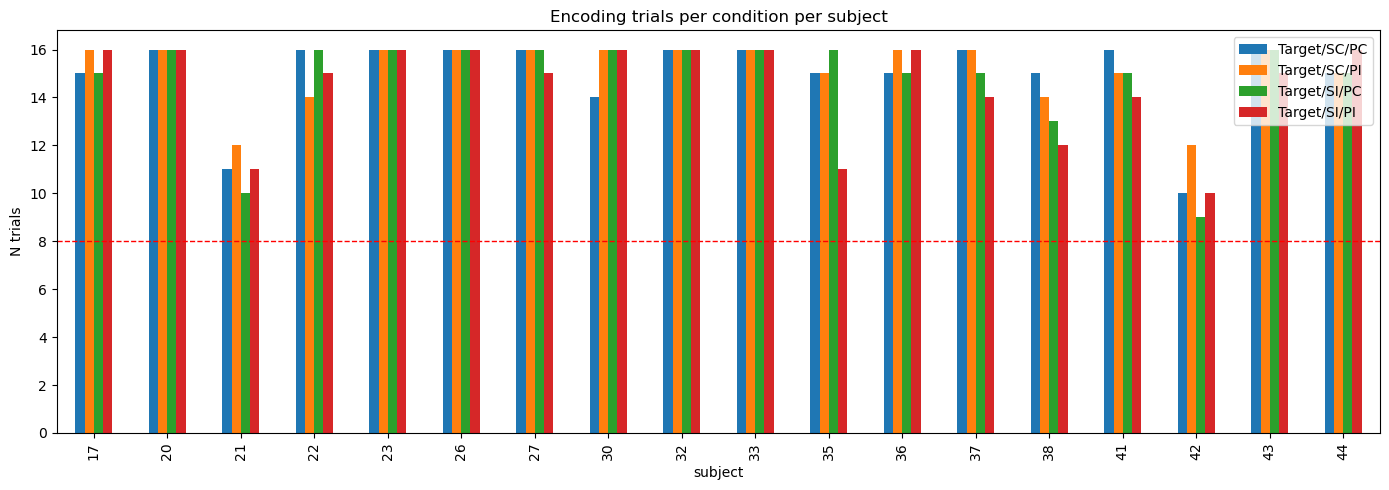

              total    average
Target/SC/PI  273.0  15.166667
Target/SI/PC  267.0  14.833333
Target/SI/PI  261.0  14.500000


In [ ]:
conditions_of_interest = ['Target/SC/PC', 'Target/SC/PI', 'Target/SI/PC', 'Target/SI/PI']
min_trials_per_cell = 8

count_records = []

for subject_id in subject_ids:
    epochs_path = (derivatives_dir / f"sub-{subject_id}" / "eeg"
                   / f"sub-{subject_id}_task-loc_desc-encoding_epo.fif")

    epochs = mne.read_epochs(epochs_path, preload=False, verbose=False)
    counts = {c: (len(epochs[c]) if c in epochs.event_id else np.nan) for c in conditions_of_interest}
    count_records.append({"subject": subject_id, **counts})

counts_df = pd.DataFrame(count_records).set_index("subject")
counts_df.to_csv(results_dir / "encoding_trial_counts_per_condition.csv")


counts_df.plot(kind='bar', figsize=(14, 5), title="Encoding trials per condition per subject")
plt.axhline(min_trials_per_cell, color='red', linestyle='--', linewidth=1)
plt.ylabel("N trials")
plt.tight_layout()
plt.savefig(results_dir / "subj_enc_trial_counts_per_condition.png", dpi=150)
plt.show()

In [17]:
summary = counts_df.iloc[:, 0:4].agg(['sum', 'mean']).T
summary.columns = ['total', 'average']
summary.index.name = 'condition_cell'
print(summary)

summary.to_csv(results_dir / 'agg_enc_trial_counts_per_condition.csv')

                total    average
condition_cell                  
Target/SC/PC    270.0  15.000000
Target/SC/PI    273.0  15.166667
Target/SI/PC    267.0  14.833333
Target/SI/PI    261.0  14.500000


In [4]:
# ==========================================
# STEP 1: Load per-subject cleaned encoding epochs, build evokeds
# ==========================================

# One list per condition/collapsed-factor, one entry per subject
evokeds = {
    'Target/SC/PC': [], 'Target/SC/PI': [], 'Target/SI/PC': [], 'Target/SI/PI': [],
    'SC': [], 'SI': [], 'PC': [], 'PI': [],
}
diff_waves = {'H4_SI_minus_SC': [], 'H5_PI_minus_PC': [], 'H6_SCPI_minus_SIPC': []}

included_subjects, skipped_subjects = [], []

for subject_id in subject_ids:
    epochs_path = (derivatives_dir / f"sub-{subject_id}" / "eeg"
                   / f"sub-{subject_id}_task-loc_desc-encoding_epo.fif")
    if not epochs_path.exists():
        skipped_subjects.append((subject_id, "epochs file not found"))
        continue

    epochs = mne.read_epochs(epochs_path, preload=True, verbose=False)

    required = ['Target/SC/PC', 'Target/SC/PI', 'Target/SI/PC', 'Target/SI/PI']
    if not all(cond in epochs.event_id for cond in required):
        skipped_subjects.append((subject_id, "missing one or more conditions"))
        continue

    # Per-condition evokeds (the four 2x2 cell means)
    ev_sc_pc = epochs['Target/SC/PC'].average()
    ev_sc_pi = epochs['Target/SC/PI'].average()
    ev_si_pc = epochs['Target/SI/PC'].average()
    ev_si_pi = epochs['Target/SI/PI'].average()

    # Collapsed main-effect evokeds: average of CELL MEANS, not pooled raw trials —
    # protects each main effect from being confounded by trial-count imbalance
    # in the *other* factor after AutoReject.
    ev_sc = mne.combine_evoked([ev_sc_pc, ev_sc_pi], weights='equal')
    ev_si = mne.combine_evoked([ev_si_pc, ev_si_pi], weights='equal')
    ev_pc = mne.combine_evoked([ev_sc_pc, ev_si_pc], weights='equal')
    ev_pi = mne.combine_evoked([ev_sc_pi, ev_si_pi], weights='equal')

    for cond, ev in [('Target/SC/PC', ev_sc_pc), ('Target/SC/PI', ev_sc_pi),
                      ('Target/SI/PC', ev_si_pc), ('Target/SI/PI', ev_si_pi),
                      ('SC', ev_sc), ('SI', ev_si), ('PC', ev_pc), ('PI', ev_pi)]:
        evokeds[cond].append(ev)

    # Per-subject difference waves — these, not the raw evokeds, are what get tested against zero
    diff_waves['H4_SI_minus_SC'].append(mne.combine_evoked([ev_si, ev_sc], weights=[1, -1]))
    diff_waves['H5_PI_minus_PC'].append(mne.combine_evoked([ev_pi, ev_pc], weights=[1, -1]))
    diff_waves['H6_SCPI_minus_SIPC'].append(mne.combine_evoked([ev_sc_pi, ev_si_pc], weights=[1, -1]))

    included_subjects.append(subject_id)

print(f"Included {len(included_subjects)} / {len(subject_ids)} subjects.")
if skipped_subjects:
    print("Skipped:", skipped_subjects)

Included 18 / 44 subjects.
Skipped: [('01', 'epochs file not found'), ('02', 'epochs file not found'), ('03', 'epochs file not found'), ('04', 'epochs file not found'), ('05', 'epochs file not found'), ('06', 'epochs file not found'), ('07', 'epochs file not found'), ('08', 'epochs file not found'), ('09', 'epochs file not found'), ('10', 'epochs file not found'), ('11', 'epochs file not found'), ('12', 'epochs file not found'), ('13', 'epochs file not found'), ('14', 'epochs file not found'), ('15', 'epochs file not found'), ('16', 'epochs file not found'), ('18', 'epochs file not found'), ('19', 'epochs file not found'), ('24', 'epochs file not found'), ('25', 'epochs file not found'), ('28', 'epochs file not found'), ('29', 'epochs file not found'), ('31', 'epochs file not found'), ('34', 'epochs file not found'), ('39', 'epochs file not found'), ('40', 'epochs file not found')]


#### 2.2 Visual Evoked Potentials
Aggregating over all epochs, do we see the characteristic VEP curve and topography?

The VEP is characterized by two positive deflections (P1, P2) that are separated by a negative deflection (the N1 wave). They can be most prominently observed at occipital/occipito-parietal electrodes, peaking at around 100–130 ms for the P1, and 150–200 ms for the posterior N1 (Luck, 2014).

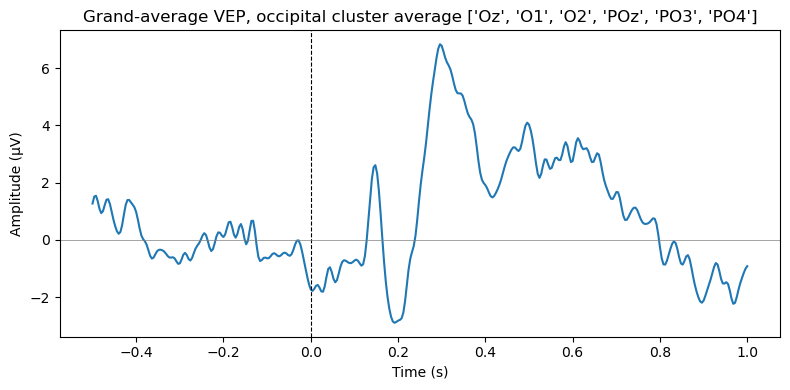

In [40]:
# Grand average across ALL trials
evoked_all = epochs.average()

# --- Create a list of occipital electrodes that should best capture the VEP ---
occipital_picks = ['Oz', 'O1', 'O2', 'POz', 'PO3', 'PO4']
occipital_picks = [ch for ch in occipital_picks if ch in evoked_all.ch_names]

# Average the time-series across the cluster electrodes
occipital_data = evoked_all.copy().pick(occipital_picks).data.mean(axis=0)
times = evoked_all.times

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, occipital_data * 1e6, color='C0')  # converion Volt to microVolt
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Grand-average VEP, occipital cluster average {occipital_picks}')

plt.tight_layout()
plt.savefig('05_veps_occipital_timecourse.png', dpi=150)
plt.show()

In [38]:
# I wonder why the stimulus onset does not correspond with 0 microVolt. Let's check whether the baseline correction worked.
# The average amplitude in the pre-stimulus time window should be zero. Looks good!
evoked_all.copy().crop(tmin=epochs.baseline[0], tmax=epochs.baseline[1]).pick(occipital_picks).data.mean()

np.float64(-6.52045303992957e-16)

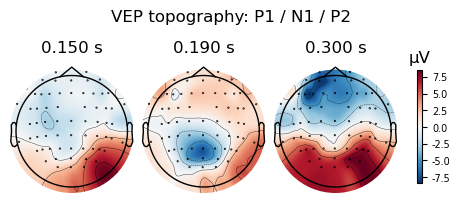

In [39]:
# --- Topoplots at key VEP latencies according to the above plot ---
times = [0.150, 0.190, 0.300]  # seconds
fig = evoked_all.plot_topomap(times=times, ch_type='eeg', show=False)
fig.suptitle('VEP topography: P1 / N1 / P2')
fig.savefig('05_veps_topomap.png', dpi=150)
plt.show()

#### 2.3 Differences in pre-stimulus period
If we find any differences in the pre-stimulus period, this would put significant condition differences that we care about, which should occur after the stimulus presentation, into question.

Event-related potentials EEG hypotheses (H)  
H4 (main effect): If schematic incongruence elicits neural responses to expectancy violations, then the difference wave across trials (schematically incongruent minus schematically congruent trials) will show temporal-spatial clusters with significant deviations from zero when tested with a permutation test.  
H5 (main effect): If perceptual incongruence elicits expectancy violations, then the difference wave across trials (perceptually incongruent minus perceptually congruent) will show temporal-spatial clusters with significant deviations from zero when tested with a permutation test.   
H6 (Direct Contrast): If schematic and perceptual violations evoke distinct neural responses, then the direct contrast between the orthogonal violation conditions (i.e., Schematic-Congruent/Perceptual-Incongruent vs. Schematic-Incongruent/Perceptual-Congruent) will show temporal-spatial clusters with significant deviations from zero when tested with a permutation test. 

### 3. Averaging and CBPT

In [43]:
# ==========================================
# STEP 1: Load per-subject cleaned encoding epochs, build evokeds
# ==========================================

# One list per condition/collapsed-factor, one entry per subject
evokeds = {
    'Target/SC/PC': [], 'Target/SC/PI': [], 'Target/SI/PC': [], 'Target/SI/PI': [],
    'SC': [], 'SI': [], 'PC': [], 'PI': [],
}
diff_waves = {'H4_SI_minus_SC': [], 'H5_PI_minus_PC': [], 'H6_SCPI_minus_SIPC': []}

included_subjects, skipped_subjects = [], []

for subject_id in subject_ids:
    epochs_path = (derivatives_dir / f"sub-{subject_id}" / "eeg"
                   / f"sub-{subject_id}_task-loc_desc-encoding_epo.fif")
    if not epochs_path.exists():
        skipped_subjects.append((subject_id, "epochs file not found"))
        continue

    epochs = mne.read_epochs(epochs_path, preload=True, verbose=False)

    required = ['Target/SC/PC', 'Target/SC/PI', 'Target/SI/PC', 'Target/SI/PI']
    if not all(cond in epochs.event_id for cond in required):
        skipped_subjects.append((subject_id, "missing one or more conditions"))
        continue

    # Per-condition evokeds (the four 2x2 cell means)
    ev_sc_pc = epochs['Target/SC/PC'].average()
    ev_sc_pi = epochs['Target/SC/PI'].average()
    ev_si_pc = epochs['Target/SI/PC'].average()
    ev_si_pi = epochs['Target/SI/PI'].average()

    # Collapsed main-effect evokeds: average of CELL MEANS, not pooled raw trials —
    # protects each main effect from being confounded by trial-count imbalance
    # in the *other* factor after AutoReject.
    ev_sc = mne.combine_evoked([ev_sc_pc, ev_sc_pi], weights='equal')
    ev_si = mne.combine_evoked([ev_si_pc, ev_si_pi], weights='equal')
    ev_pc = mne.combine_evoked([ev_sc_pc, ev_si_pc], weights='equal')
    ev_pi = mne.combine_evoked([ev_sc_pi, ev_si_pi], weights='equal')

    for cond, ev in [('Target/SC/PC', ev_sc_pc), ('Target/SC/PI', ev_sc_pi),
                      ('Target/SI/PC', ev_si_pc), ('Target/SI/PI', ev_si_pi),
                      ('SC', ev_sc), ('SI', ev_si), ('PC', ev_pc), ('PI', ev_pi)]:
        evokeds[cond].append(ev)

    # Per-subject difference waves — these, not the raw evokeds, are what get tested against zero
    diff_waves['H4_SI_minus_SC'].append(mne.combine_evoked([ev_si, ev_sc], weights=[1, -1]))
    diff_waves['H5_PI_minus_PC'].append(mne.combine_evoked([ev_pi, ev_pc], weights=[1, -1]))
    diff_waves['H6_SCPI_minus_SIPC'].append(mne.combine_evoked([ev_sc_pi, ev_si_pc], weights=[1, -1]))

    included_subjects.append(subject_id)

print(f"Included {len(included_subjects)} / {len(subject_ids)} subjects.")
if skipped_subjects:
    print("Skipped:", skipped_subjects)

Included 18 / 18 subjects.


Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


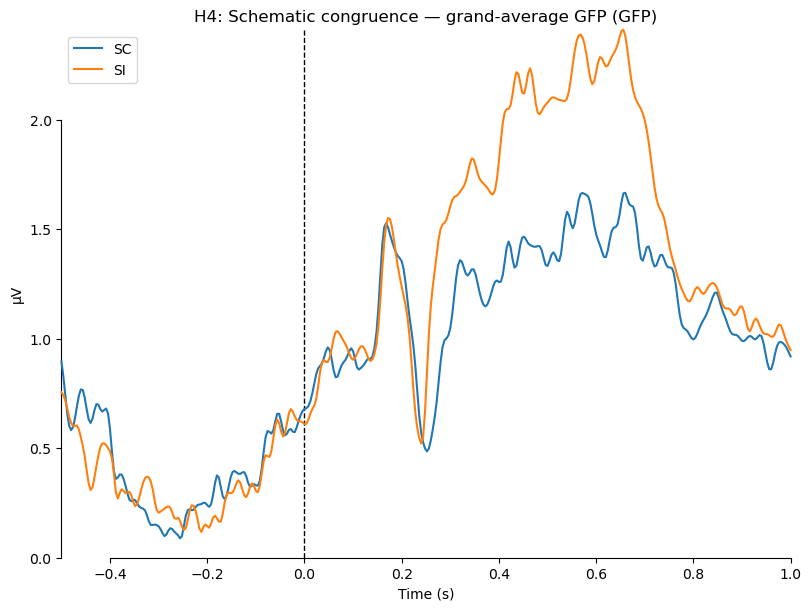

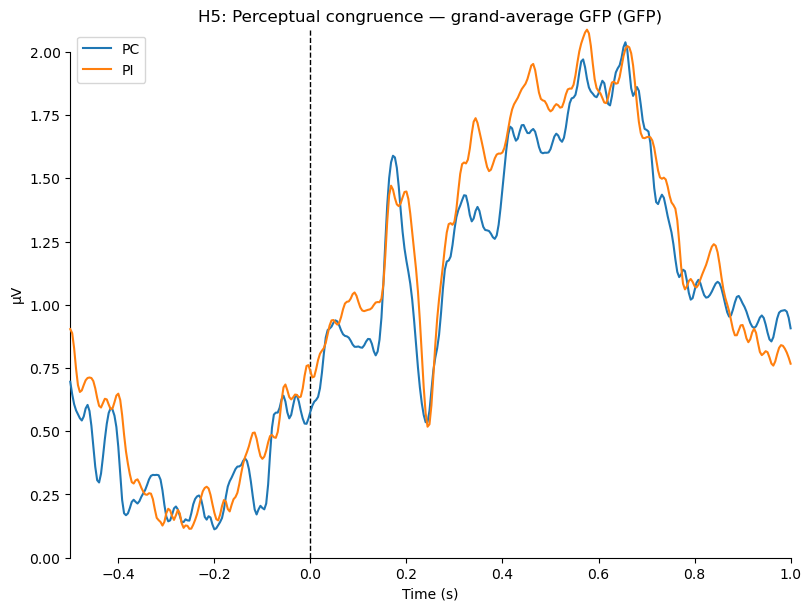

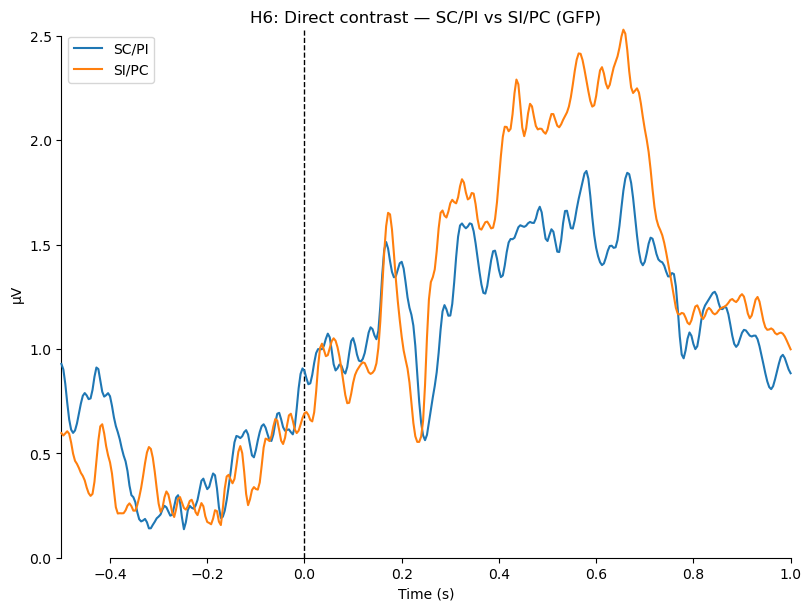

In [44]:
# ==========================================
# STEP 2: Grand averages + QC waveform plots
# ==========================================

grand_averages = {cond: mne.grand_average(evs) for cond, evs in evokeds.items()}

fig = mne.viz.plot_compare_evokeds(
    {'SC': grand_averages['SC'], 'SI': grand_averages['SI']},
    picks='eeg', combine='gfp', show=False,
    title="H4: Schematic congruence — grand-average GFP"
)
fig[0].savefig(results_dir / "01_gfp_SC_vs_SI.png", dpi=150)

fig = mne.viz.plot_compare_evokeds(
    {'PC': grand_averages['PC'], 'PI': grand_averages['PI']},
    picks='eeg', combine='gfp', show=False,
    title="H5: Perceptual congruence — grand-average GFP"
)
fig[0].savefig(results_dir / "02_gfp_PC_vs_PI.png", dpi=150)

fig = mne.viz.plot_compare_evokeds(
    {'SC/PI': grand_averages['Target/SC/PI'], 'SI/PC': grand_averages['Target/SI/PC']},
    picks='eeg', combine='gfp', show=False,
    title="H6: Direct contrast — SC/PI vs SI/PC"
)
fig[0].savefig(results_dir / "03_gfp_direct_contrast.png", dpi=150)

In [45]:
# ==========================================
# STEP 3: Channel adjacency (needed for spatio-temporal clustering)
# ==========================================

# Adjacency defines which electrodes count as "neighbors" for cluster formation —
# a cluster must be contiguous in BOTH time and space (electrode) to count as one cluster.
adjacency, ch_names = find_ch_adjacency(grand_averages['SC'].info, ch_type='eeg')

assert ch_names == grand_averages['SC'].ch_names, (
    "Channel order mismatch between adjacency and evoked data — fix before running the test."
)

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.


-- number of adjacent vertices : 63


In [46]:
# ==========================================
# STEP 4: Cluster-based permutation tests (H4, H5, H6)
# ==========================================

# Comment

alpha = 0.05
n_permutations = 500
random_state = 97

def run_cluster_test(diff_evokeds, label):
    """One-sample spatio-temporal cluster permutation test against zero.

    diff_evokeds: list of mne.Evoked, one per subject (the per-subject difference wave).
    """
    # X must be shape (n_subjects, n_times, n_channels) — evoked.data is (n_channels, n_times),
    # so each subject's array gets transposed before stacking.
    X = np.array([ev.data.T for ev in diff_evokeds])

    t_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_1samp_test(
        X,
        threshold=None,      # None -> MNE derives a t-threshold from alpha=0.05 given the df;
                             # switch to threshold_tfce=dict(start=0, step=0.2) for TFCE if you
                             # want to avoid picking a cluster-forming threshold at all
        n_permutations=n_permutations,
        tail=0,              # two-tailed: "significant deviations from zero" in either direction
        adjacency=adjacency,
        n_jobs=1,
        seed=random_state,
        out_type='mask',
        verbose=False,
    )

    sig_clusters = [(i, p) for i, p in enumerate(cluster_p_values) if p < alpha]

    print(f"\n{label}: {len(clusters)} clusters found, {len(sig_clusters)} significant (p < {alpha})")
    for i, p in sig_clusters:
        mask = clusters[i]
        times_idx, ch_idx = np.where(mask)
        t_start = diff_evokeds[0].times[times_idx.min()]
        t_end = diff_evokeds[0].times[times_idx.max()]
        involved_chs = sorted({diff_evokeds[0].ch_names[c] for c in ch_idx})
        print(f"  Cluster {i}: p = {p:.4f}, window = [{t_start:.3f}, {t_end:.3f}] s, "
              f"{len(involved_chs)} channels")

    return {
        't_obs': t_obs, 'clusters': clusters,
        'cluster_p_values': cluster_p_values, 'H0': H0,
        'significant_clusters': sig_clusters,
    }

results = {}
results['H4'] = run_cluster_test(diff_waves['H4_SI_minus_SC'], "H4 (Schematic incongruence)")
results['H5'] = run_cluster_test(diff_waves['H5_PI_minus_PC'], "H5 (Perceptual incongruence)")
results['H6'] = run_cluster_test(diff_waves['H6_SCPI_minus_SIPC'], "H6 (Direct contrast)")


H4 (Schematic incongruence): 89 clusters found, 2 significant (p < 0.05)
  Cluster 30: p = 0.0100, window = [0.244, 0.744] s, 23 channels
  Cluster 73: p = 0.0400, window = [0.336, 1.000] s, 28 channels

H5 (Perceptual incongruence): 111 clusters found, 0 significant (p < 0.05)

H6 (Direct contrast): 105 clusters found, 1 significant (p < 0.05)
  Cluster 96: p = 0.0420, window = [0.368, 0.744] s, 16 channels


#### Quality Check 3: No significant differences between conditions in the pre-stimulus baseline window

In [ ]:
def crop_to_baseline(diff_evokeds, tmin, tmax):
    return [ev.copy().crop(tmin=tmin, tmax=tmax) for ev in diff_evokeds]

print(epochs.baseline)

baseline_tmin, baseline_tmax = epochs.baseline  # reuse your existing baseline window

results['baseline_QC_H4'] = run_cluster_test(
    crop_to_baseline(diff_waves['H4_SI_minus_SC'], baseline_tmin, baseline_tmax),
    "Baseline QC (H4 conditions)"
)
# same for H5/H6 diff waves if you want to check all three condition contrasts

def crop_to_baseline(diff_evokeds, tmin, tmax):
    return [ev.copy().crop(tmin=tmin, tmax=tmax) for ev in diff_evokeds]

results['baseline_QC_H5'] = run_cluster_test(
    crop_to_baseline(diff_waves['H4_SI_minus_SC'], baseline_tmin, baseline_tmax),
    "Baseline QC (H5 conditions)"
)
# same for H5/H6 diff waves if you want to check all three condition contrasts


Baseline QC (H4 conditions): 46 clusters found, 0 significant (p < 0.05)

Baseline QC (H5 conditions): 46 clusters found, 0 significant (p < 0.05)


In [16]:
# ==========================================
# STEP 5: Visualize significant clusters
# ==========================================

def plot_significant_clusters(diff_evokeds, cluster_result, label, out_prefix):
    grand_diff = mne.grand_average(diff_evokeds)

    for i, p in cluster_result['significant_clusters']:
        mask = cluster_result['clusters'][i]  # shape (n_times, n_channels), boolean
        times_idx, ch_idx = np.where(mask)
        t_start, t_end = grand_diff.times[times_idx.min()], grand_diff.times[times_idx.max()]
        t_mid_idx = int(np.round((times_idx.min() + times_idx.max()) / 2))

        chs_in_cluster_here = mask[t_mid_idx, :]  # which channels were "in" the cluster at this instant

        fig, ax = plt.subplots(figsize=(4, 4))
        mne.viz.plot_topomap(
            grand_diff.data[:, t_mid_idx], grand_diff.info,
            mask=chs_in_cluster_here, axes=ax, show=True
        )
        ax.set_title(f"{label} cluster {i} (p={p:.3f})\n"
                      f"{t_start:.3f}-{t_end:.3f}s, shown at {grand_diff.times[t_mid_idx]:.3f}s")
        fig.savefig(results_dir / f"{out_prefix}_cluster{i}_topomap.png", dpi=150)
        plt.close(fig)

plot_significant_clusters(diff_waves['H4_SI_minus_SC'], results['H4'], "H4", "04_H4")
plot_significant_clusters(diff_waves['H5_PI_minus_PC'], results['H5'], "H5", "05_H5")
plot_significant_clusters(diff_waves['H6_SCPI_minus_SIPC'], results['H6'], "H6", "06_H6")

Identifying common channels ...


Identifying common channels ...
Identifying common channels ...


In [17]:
# ==========================================
# STEP 6: Save results
# ==========================================

with open(results_dir / "cluster_test_results.pkl", "wb") as f:
    pickle.dump(results, f)

summary = {
    "included_subjects": included_subjects,
    "skipped_subjects": skipped_subjects,
    "n_permutations": n_permutations,
    "alpha": alpha,
}
for hyp, res in results.items():
    summary[hyp] = {
        "n_clusters_total": len(res['clusters']),
        "significant_clusters": [
            {"cluster_index": i, "p_value": float(p)} for i, p in res['significant_clusters']
        ],
    }

with open(results_dir / "averaging_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "included_subjects": [
    "17",
    "20",
    "21",
    "22",
    "23",
    "26",
    "27",
    "30",
    "32",
    "33",
    "35",
    "36",
    "37",
    "38",
    "41",
    "42",
    "43",
    "44"
  ],
  "skipped_subjects": [
    [
      "01",
      "epochs file not found"
    ],
    [
      "02",
      "epochs file not found"
    ],
    [
      "03",
      "epochs file not found"
    ],
    [
      "04",
      "epochs file not found"
    ],
    [
      "05",
      "epochs file not found"
    ],
    [
      "06",
      "epochs file not found"
    ],
    [
      "07",
      "epochs file not found"
    ],
    [
      "08",
      "epochs file not found"
    ],
    [
      "09",
      "epochs file not found"
    ],
    [
      "10",
      "epochs file not found"
    ],
    [
      "11",
      "epochs file not found"
    ],
    [
      "12",
      "epochs file not found"
    ],
    [
      "13",
      "epochs file not found"
    ],
    [
      "14",
      "epochs file not found"
  